In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
import matplotlib.pyplot as plt
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
INPUT_FEATURES = 10
NUM_CLASSES = 2
TRAIN_RATIO = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:{device}")
class RandomDataset(Dataset):
    def __init__(self,num_samples=1000,input_dim=10,num_classes=2):
        self.X = torch.randn(num_samples,input_dim)
        self.y = torch.randint(0,num_classes,(num_samples,))
    def __len__(self):
        return len(self.x)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]
full_dataset = RandomDataset(num_samples=1000,input_dim=INPUT_FEATURES,num_classes=NUM_CLASSES)
train_size = int(TRAIN_RATIO * len(full_dataset))
val_size = len(full_dataset) - train_size

Using device:cuda


In [6]:
class SingletonMeta(type):
    _instances = {}
    def __call__(cls,*args,**kwargs):
        if cls not in cls._instances:
            cls._instances[cls] = super().__call__(*args,**kwargs)
        return cls._instances[cls]
class Logger(metaclass=SingletonMeta):
    def __init__(self):
        self.logs = []
    def info(self,msg):
        self.logs.append(f"[INFO]{msg}")
a = Logger();b = Logger()
print(a is b)
a.info("启动");b.info("就绪")
print(a.logs)

True
['[INFO]启动', '[INFO]就绪']


In [9]:
from abc import ABC,abstractmethod
class Notification(ABC):
    @abstractmethod
    def send(self,to:str,content:str): ...
class Email(Notification):
    def send(self,to,content):
        print(f"📧 邮件 → {to}: {content[:20]}...")
class SMS(Notification):
    def send(self,to,content):
        print(f"📱 短信 → {to}: {content[:20]}...")
class WeChat(Notification):
    def send(self,to,content):
        print(f"💬 微信 → {to}: {content[:20]}...")
class NotificationFactory:
    _map = {"email":Email,"sms":SMS,"wechat":WeChat}
    @classmethod
    def create(cls,kind:str) -> Notification:
        cls._map[kind]
        return cls._map[kind]()
    @classmethod
    def register(cls,kind,cls_):
        cls._map[kind] = cls
NotificationFactory.create("email").send("user@a.com","您的验证码是1234")

📧 邮件 → user@a.com: 您的验证码是1234...


In [12]:
class Event:
    def __init__(self):
        self._handlers = []
    def connect(self,handler):
        self._handlers.append(handler)
        return handler
    def disconnect(self,handler):
        self._handlers.remove(handler)
    def emit(self,*args,**kwargs):
        for h in self._handlers:
            h(*args,**kwargs)
class Stock:
    def __init__(self,symbol,price):
        self.symbol = symbol
        self._price = price
        self.changed = Event()
    @property
    def price(self):
        return self._price
    @price.setter
    def price(self,value):
        if value != self._price:
            self._price = value
            self.changed.emit(self.symbol,value)
class Alert:
    def __init__(self,symbol,threshold,direction="above"):
        self.symbol,self.threshold,self.direction = symbol,threshold,direction
    def on_price(self,symbol,price):
        if symbol != self.symbol:
            return 
        if self.direction == "above" and price >= self.threshold:
            print(f"🚨 {symbol} 突破 {self.threshold}，现价 {price}")
        elif self.direction == "below" and price <= self.threshold:
            print(f"🚨 {symbol} 跌破 {self.threshold}，现价 {price}")
stock = Stock("AAPL",170)
stock.changed.connect(Alert("AAPL",180,"above").on_price)
stock.price = 175
stock.price = 182

🚨 AAPL 突破 180，现价 182


In [13]:
def safe_div(a,b):
    try:
        result = a / b
    except ZeroDivisionError:
        print("除数不能为 0")
        return None
    except TypeError as e:
        print(f"类型错误:{e}")
        return None
    except (ValueError,KeyError):
        print("值或键有问题")
        return None
    else:
        print("计算成功")
        return result
    finally:
        print("清理完毕")
print(safe_div(10,2))
print(safe_div(10,0))

计算成功
清理完毕
5.0
除数不能为 0
清理完毕
None


In [15]:
d = {"a":1}
try:
    print(d["b"])
except KeyError as e:
    print(f"键不存在: {e}")
def read_config(path):
    try:
        data = open(path,encoding="utf-8").read()
        return eval(data)
    except FileNotFoundError:
        print(f"配置文件不存在: {path}")
    except PermissionError:
        print(f"没有读取权限: {path}")
    except SyntaxError as e:
        print(f"配置文件语法错误: {e}")
    except Exception as e:
        print(f"未知错误: {type(e).__name__}: {e}")
        raise

键不存在: 'b'


In [16]:
def set_age(age):
    if not isinstance(age,int):
        raise TypeError(f"age 必须是 int，得到 {type(age).__name__}")
    if age < 0 or age > 150:
        raise ValueError(f"age 必须在 0~150 之间，得到 {age}")
    return age
set_age(-1)

ValueError: age 必须在 0~150 之间，得到 -1

In [ ]:
import json
def load_json(path):
    try:
        return json.load(open(path,encoding="utf-8"))
    except json.JSONDecodeError as e:
        print(f"JSON 解析失败，尝试修复...")
        raise 
class ConfigError(Exception):
    def load_config(path):
        try:
            return json.load(open(path,encoding="utf-8"))
        except FileNotFoundError as e:
            raise ConfigError(f"配置文件缺失: {path}") from e
        except json.JSONDecodeError as e:
            raise ConfigError(f"配置文件格式非法: {path}") from e

In [20]:
class AppError(Exception):
    def __init__(self,message,code=None):
        super().__init__(message)
        self.message = message
        self.code = code or self.__class__.__name__
class ValidationError(AppError):
    pass
class NotFoundError(AppError):
    pass
class PermissionError(AppError):
    pass
class BusinessRuleError(AppError):
    pass
class ExternalServiceError(AppError):
    def __init__(self,message,service,retry_after=None):
        super().__init__(message)
        self.service = service
        self.retry_after = retry_after
def withdraw(balance,amount):
    if amount <= 0:
        raise ValidationError("取款金额必须为正数", code="INVALID_AMOUNT")
    if amount > balance:
        raise BusinessRuleError(f"余额不足：余额{balance}，请求{amount}", code="INSUFFICIENT_FUNDS")
    return balance - amount
try:
    withdraw(100,150)
except ValidationError as e:
    print(f"参数错误 [{e.code}]: {e.message}")
except BusinessRuleError as e:
    print(f"业务拒绝 [{e.code}]: {e.message}")
except AppError as e:
    print(f"应用错误 [{e.code}]: {e}")

业务拒绝 [INSUFFICIENT_FUNDS]: 余额不足：余额100，请求150


In [26]:
import traceback
import logging
import sys
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
log = logging.getLogger("app")
def risky():
    {}["missing"]
try:
    risky()
except KeyError:
    log.exception("查询用户配置失败")
try:
    risky()
except Exception:
    tb_text = traceback.format_exc()
    log.error("发生异常:\n%s", tb_text)
try:
    risky()
except Exception:
    traceback.print_exc()
import traceback
def summarize(exc_info):
    ex_type,ex_val,tb = exc_info
    last = traceback.extract_tb(tb)[-1]
    return (f"{ex_type.__name__}: {ex_val} "
            f"@ {last.filename}:{last.lineno} in {last.name}")
try:
    risky()
except Exception:
    print(summarize(sys.exc_info()))

2026-09-22 15:51:49,835 [ERROR] app: 查询用户配置失败
Traceback (most recent call last):
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 13, in <module>
    risky()
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 11, in risky
    {}["missing"]
    ~~^^^^^^^^^^^
KeyError: 'missing'
2026-09-22 15:51:49,836 [ERROR] app: 发生异常:
Traceback (most recent call last):
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 17, in <module>
    risky()
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 11, in risky
    {}["missing"]
    ~~^^^^^^^^^^^
KeyError: 'missing'

KeyError: 'missing' @ C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py:11 in risky


Traceback (most recent call last):
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 22, in <module>
    risky()
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\1662997928.py", line 11, in risky
    {}["missing"]
    ~~^^^^^^^^^^^
KeyError: 'missing'


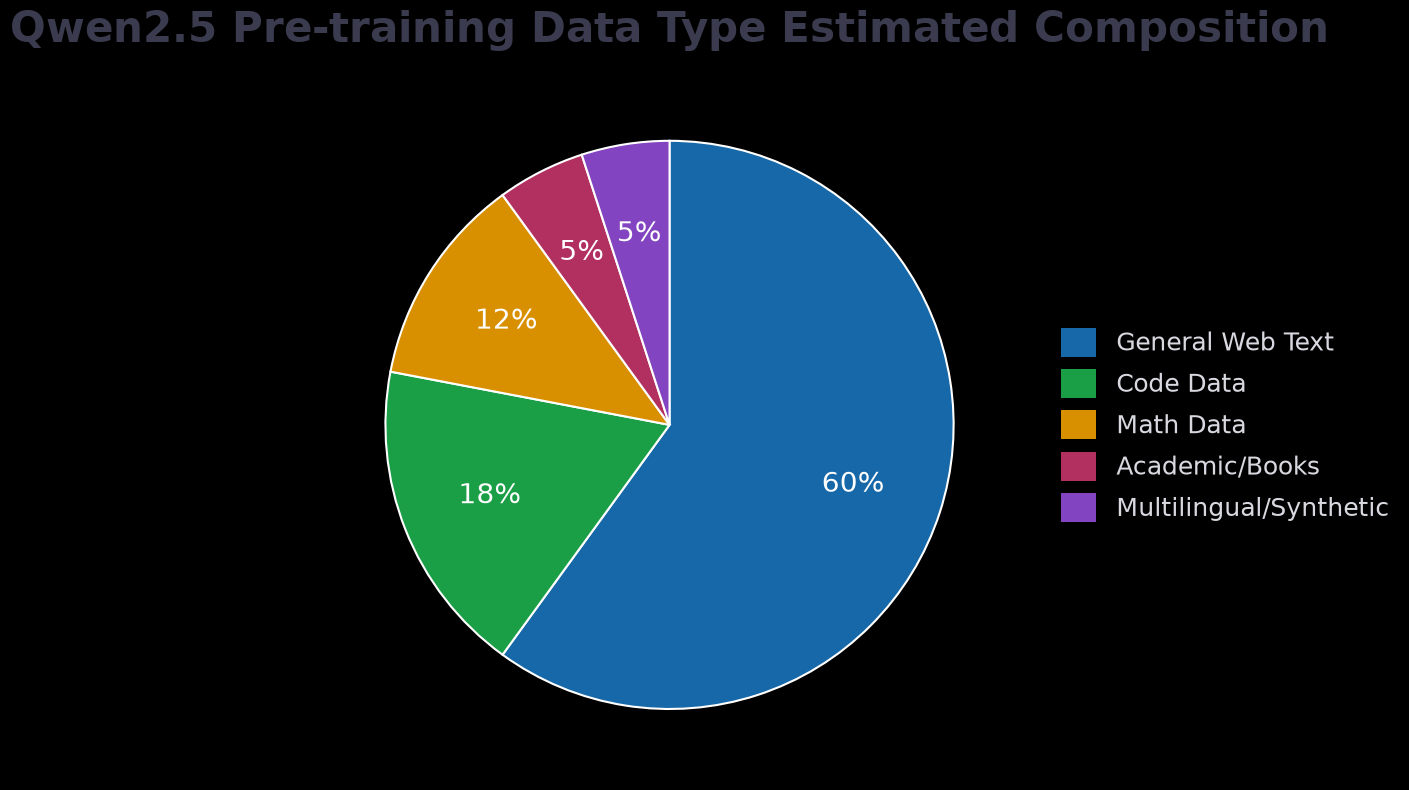

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- Data ----------
labels = ['General Web Text', 'Code Data', 'Math Data',
          'Academic/Books', 'Multilingual/Synthetic']
sizes  = [60, 18, 12, 5, 5]
colors = ['#1768A8', '#1A9E46', '#D99000', '#B13060', '#8244C0']

# ---------- Figure (black background) ----------
fig, ax = plt.subplots(figsize=(14, 8), facecolor='black')
ax.set_facecolor('black')

# ---------- Pie chart ----------
wedges, _, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,          # start at 12 o'clock
    counterclock=False,     # draw clockwise
    pctdistance=0.68,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 20},
)

# ---------- Title (dark gray, like the original) ----------
ax.set_title('Qwen2.5 Pre-training Data Type Estimated Composition',
             color='#3B3B4F', fontsize=30, fontweight='bold', pad=20)

# ---------- Legend (square patches on the right) ----------
handles = [Patch(facecolor=c, edgecolor='none') for c in colors]
ax.legend(handles, labels,
          loc='center left',
          bbox_to_anchor=(1.02, 0.5),
          frameon=False,
          labelcolor='#D8D8E0',
          fontsize=18,
          handlelength=1.4,
          handleheight=1.4)

plt.tight_layout()
plt.savefig('qwen25_data_composition.png', dpi=150,
            facecolor='black', bbox_inches='tight')
plt.show()


In [25]:
def helper(x):
    return 1 / x
def public_fn(x):
    try:
        return helper(x)
    except Exception:
        traceback.print_exc(limit=2)
public_fn(0)

Traceback (most recent call last):
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\3342124322.py", line 5, in public_fn
    return helper(x)
           ^^^^^^^^^
  File "C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24424\3342124322.py", line 2, in helper
    return 1 / x
           ~~^~~
ZeroDivisionError: division by zero
